You are a data analyst working for a tech company closely monitoring the AI tools market. You want to understand the evolving popularity of three major AI tools, ChatGPT, Gemini, and Microsoft Copilot, and identify which tool is gaining the most traction and how they compare over time.


<img src="ai_tools.jpg" align="center"/>

You'll work with real-world time series data that captures the global interest in these tools over several weeks. Your goal is to analyze this data, uncover patterns, and provide actionable insights to help your company make informed decisions. This might include determining where to focus marketing efforts, predicting future trends, or identifying potential areas for improvement.

Are you ready to help your company stay ahead of the curve in the competitive AI tools market? Let's get started!

### The Data

The Google Trends data is available as a CSV file `ai_tools_comparison.csv`.
The data contains the number of worldwide searches for chatGpt, Gemini, and Microsoft Copilot over the past 12 months as of September 2024. 
<!--- Link to query: https://trends.google.com/trends/explore?q=chatgpt,gemini,%2Fg%2F11tsqm45vd&hl=en-US -->

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
trends = pd.read_csv('ai_tools_comparison.csv')

# Inspect the data
trends.head()

,week,chatgpt,gemini,microsoft_copilot
0,2023-08-27,56,3,1
1,2023-09-03,56,3,1
2,2023-09-10,63,3,1
3,2023-09-17,64,3,1
4,2023-09-24,66,3,1


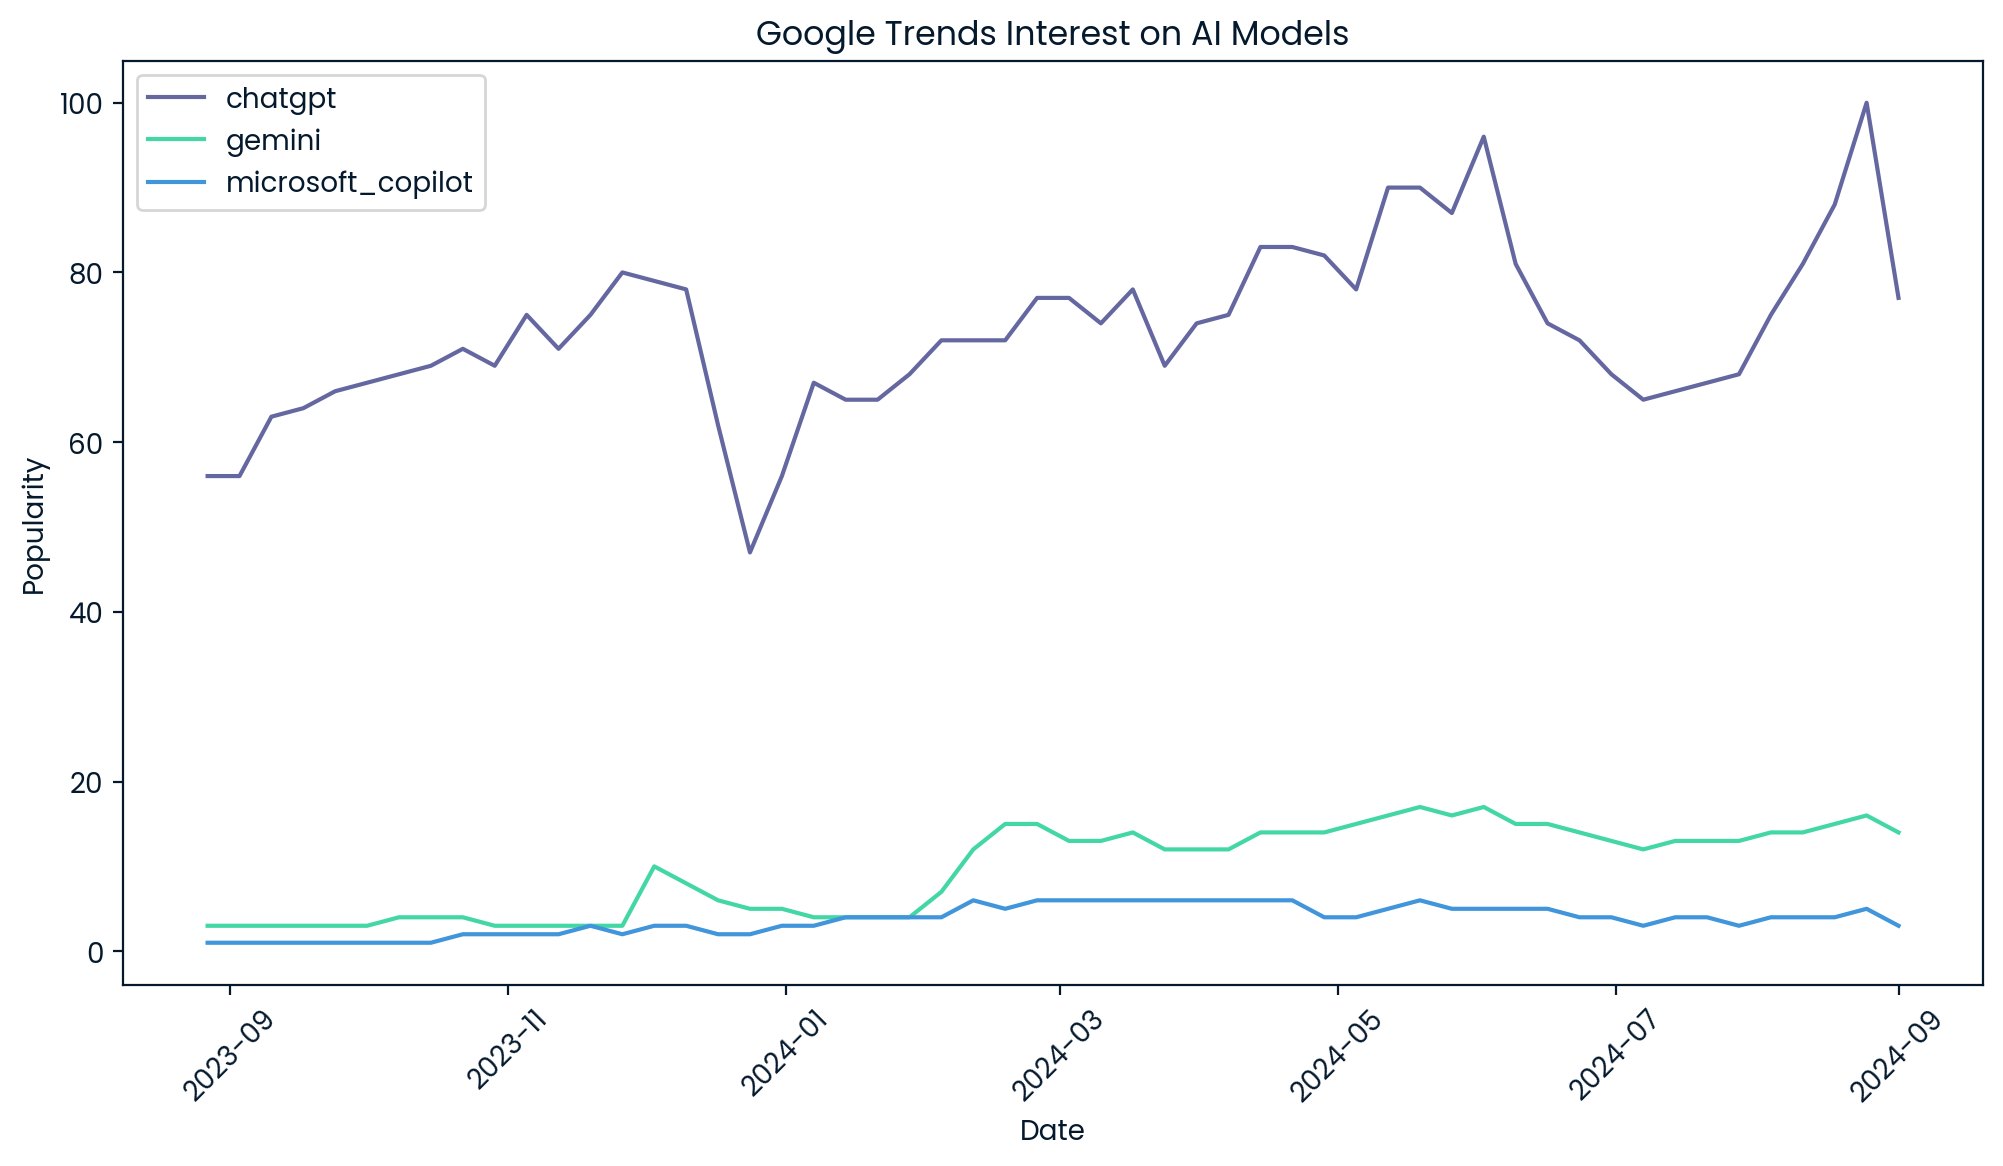

Most Consistent Model:  chatgpt
Largest Decline for ChatGPT:  December 2023
Best Month in AI Interest:  May


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

#Reading the data from CSV file
trends = pd.read_csv('ai_tools_comparison.csv')

#Convert content from week column into datetime datatype
trends['week'] = pd.to_datetime(trends['week'])
weekly_diff = trends[['chatgpt', 'gemini', 'microsoft_copilot']].diff()
most_consistent = weekly_diff.mean().idxmax() #use mean to find the most consistent Ai

#Graph plotting happens below, including extra labels for cleaner presentation.
plt.figure(figsize=(12, 6))
plt.plot(trends['week'], trends['chatgpt'], label='chatgpt')
plt.plot(trends['week'], trends['gemini'], label='gemini')
plt.plot(trends['week'], trends['microsoft_copilot'], label='microsoft_copilot')
plt.xlabel('Date')
plt.ylabel('Popularity')
plt.title('Google Trends Interest on AI Models')
plt.legend() #shows which line represents which ai
plt.xticks(rotation=45) #rotated to prevent dates to overlap
plt.show()

#Finding largest decline in ChatGPT interest
gpt_dip_idx = trends['chatgpt'].idxmin()
gpt_dip = trends.loc[gpt_dip_idx, 'week'].strftime('%B %Y')

#Exploring seasonality as the Lab requires
trends['month'] = trends['week'].dt.month_name()
monthly_avg = trends.groupby('month')[['chatgpt', 'gemini', 'microsoft_copilot']].mean() #breaks down into months
monthly_avg['overall_avg'] = monthly_avg.mean(axis=1) #takes those months and take average.
best_month = monthly_avg['overall_avg'].idxmax()  #Best month stored here

#prints verdicts below graphs
print("Most Consistent Model: ", most_consistent)
print("Largest Decline for ChatGPT: ", gpt_dip)
print("Best Month in AI Interest: ", best_month)